# Spike Investigation: Anomaly Detection + Attribution

Companion notebook to `design_proposal.md`. This notebook generates the synthetic dataset,
runs the anomaly detector, trains the attribution model, and inspects results end to end.

For a single-command, non-interactive run that writes all outputs (CSVs, plots, narratives) to
`output/`, use `python run_pipeline.py` instead - this notebook re-runs the same code paths but
narrates and visualizes each step for review.

In [1]:
import sys
sys.path.insert(0, "src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_generator import generate_dataset, CAUSE_TYPES
from anomaly_detection import build_scores, detect
from attribution import (
    build_feature_table, build_training_set, train_and_evaluate,
    predict_distribution, narrate, FEATURE_COLS,
)

pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 110

## 1. Synthetic data

See `design_proposal.md` -> *Data strategy* for the generative design. Quick shape check:

In [2]:
data = generate_dataset()
panel, events, labels = data["panel"], data["events"], data["labels"]
print("panel:", panel.shape, " events:", events.shape, " labeled anomaly-months:", labels.shape)
panel.head()

panel: (1752, 14)  events: (70, 11)  labeled anomaly-months: (383, 11)


,brand,channel,month,month_idx,spend,revenue,roas,iroas,mas,rroi,ctr,cpc,picr,impression_share
0,Aster Wellness,audio,2023-01,0,40253.987562,69070.179098,1.715859,1.642021,63737.236658,1.583377,0.005015,0.899637,0.057643,0.452960
1,Aster Wellness,audio,2023-02,1,43187.169016,69608.072574,1.611777,1.776745,69541.147131,1.602172,0.005101,0.687238,0.049390,0.440634
2,Aster Wellness,audio,2023-03,2,45001.625401,71322.355728,1.584884,1.545634,81547.250573,1.725978,0.004768,0.768565,0.052421,0.437148
3,Aster Wellness,audio,2023-04,3,40517.368690,59486.451491,1.468172,1.359007,67925.703144,1.690340,0.004784,0.872089,0.048230,0.451147
4,Aster Wellness,audio,2023-05,4,39879.702512,63673.961746,1.596651,1.447475,59458.471203,1.592278,0.004172,0.822171,0.046384,0.450424


In [3]:
panel[["spend", "revenue", "roas", "iroas", "mas", "rroi", "ctr", "cpc", "picr"]].describe().T

,count,mean,std,min,25%,50%,75%,max
spend,1697.0,58329.746540,42147.863135,4513.217261,27291.383294,43357.592415,81392.336578,288157.690683
revenue,1697.0,185505.210817,147604.502818,28775.365825,84744.382791,127956.627607,250833.930220,952548.542701
roas,1697.0,3.338688,1.306539,0.993779,2.357872,3.107440,4.137860,10.171309
iroas,1697.0,2.469299,0.862902,0.908741,1.807683,2.297647,3.085005,7.013742
mas,1697.0,138982.513635,114425.485207,12449.819843,65236.626266,101985.765997,173801.090207,808458.275813
rroi,1697.0,2.476994,0.839816,0.897426,1.821394,2.318605,3.132673,6.024530
ctr,1723.0,0.018319,0.014945,0.002534,0.006398,0.012062,0.027916,0.081737
cpc,1584.0,1.173820,0.392652,0.382001,0.891358,1.102724,1.386831,2.408329
picr,1709.0,0.101752,0.048226,0.033678,0.060457,0.090044,0.138838,0.322728


A sample of injected ground-truth events (used only for evaluation, never as a model feature):

In [4]:
events.sample(8, random_state=1).sort_values("start_month")

,event_id,event_key,brand,brands,category,channels,scope,start_month,end_month,shape,causes
26,1,brand:Crestline Beverages#1,Crestline Beverages,Crestline Beverages,food_beverage,"paid_search,tv",channel,2024-01,2024-03,gradual,genuine_efficiency_gain:0.35;creative_refresh:...
36,3,brand:Halcyon Personal Care#3,Halcyon Personal Care,Halcyon Personal Care,home_personal_wellness,"paid_search,social",channel,2024-02,2024-04,gradual,spend_reduction_artifact:1.00
27,2,brand:Crestline Beverages#2,Crestline Beverages,Crestline Beverages,food_beverage,social,channel,2024-09,2024-09,sudden,survivorship_bias:1.00
65,1,category:food_beverage#1,CATEGORY,"Solstice Foods,Verdant Snacks,Crestline Bevera...",food_beverage,"affiliate,audio,digital_video,display,ooh,paid...",category_wide,2025-02,2025-02,sudden,external_demand_spike:0.88
60,2,brand:Pinebrook Pet Co.#2,Pinebrook Pet Co.,Pinebrook Pet Co.,home_personal_wellness,retail_media,channel,2025-02,2025-02,sudden,creative_refresh:1.00
49,9,brand:Ridgeway Grocery#9,Ridgeway Grocery,Ridgeway Grocery,food_beverage,display,channel,2025-02,2025-04,gradual,spend_reduction_artifact:1.00
66,2,category:food_beverage#2,CATEGORY,"Solstice Foods,Verdant Snacks,Crestline Bevera...",food_beverage,"affiliate,audio,digital_video,display,ooh,paid...",category_wide,2025-09,2025-09,sudden,external_demand_spike:1.00
54,4,brand:Aster Wellness#4,Aster Wellness,Aster Wellness,home_personal_wellness,retail_media,channel,2025-09,2025-11,gradual,genuine_efficiency_gain:1.00


## 2. Anomaly detection

Baseline = own trailing robust trend + channel-level seasonal index, shrunk toward peer
(same-channel, other-brand) trend/variance for short-history brand-channels. Residuals are
turned into robust (MAD-based) z-scores; `sudden_z` catches 1-month step changes, `gradual_z`
catches slow 3-month ramps.

In [5]:
det = detect(panel, labels)
scored, sel, detector_cv = det["scored"], det["threshold_selection"], det["cv_evaluation"]
print(f"deployment threshold={sel['best_threshold']:.2f}")
print(f"brand-held-out precision={detector_cv['precision']:.2f}  recall={detector_cv['recall']:.2f}")
print(f"{scored['flagged'].sum()} of {len(scored)} brand-channel-months flagged at the deployment threshold")

deployment threshold=0.50
brand-held-out precision=0.46  recall=0.76
629 of 1752 brand-channel-months flagged at the deployment threshold


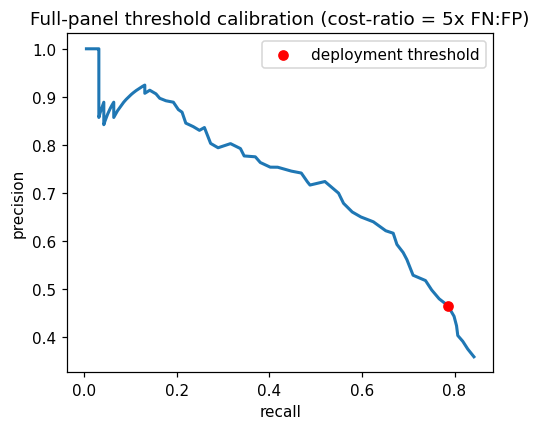

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(sel["curve"]["recall"], sel["curve"]["precision"], lw=2)
best_row = sel["curve"].iloc[(sel["curve"]["threshold"] - sel["best_threshold"]).abs().idxmin()]
ax.scatter([best_row["recall"]], [best_row["precision"]], color="red", zorder=5, label="deployment threshold")
ax.set_xlabel("recall"); ax.set_ylabel("precision"); ax.legend()
ax.set_title("Full-panel threshold calibration (cost-ratio = 5x FN:FP)")
plt.show()

Example series - ROAS vs. the model's expected baseline, with flagged months marked:

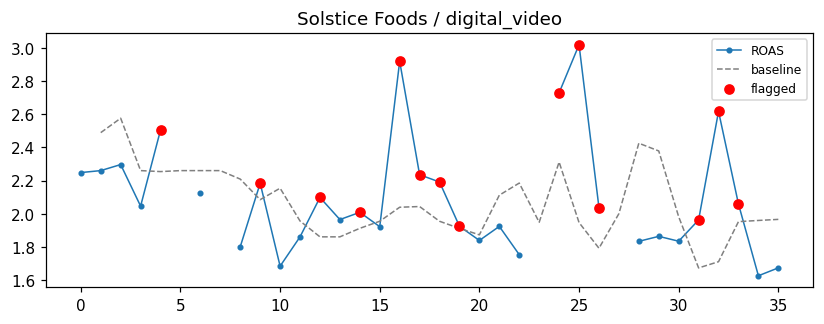

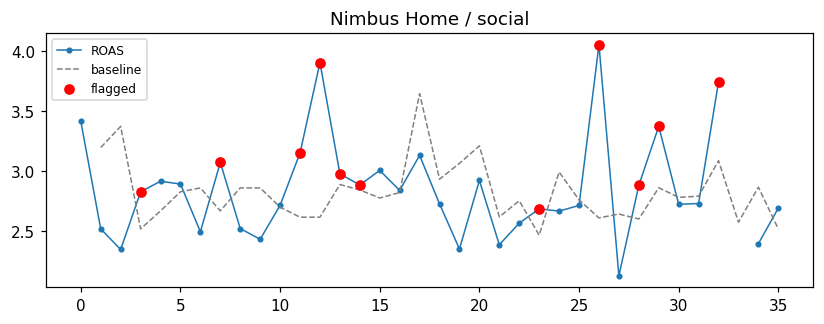

In [7]:
def plot_series(brand, channel):
    s = scored[(scored.brand == brand) & (scored.channel == channel)].sort_values("month_idx")
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(s["month_idx"], s["roas"], marker="o", ms=3, lw=1, label="ROAS")
    ax.plot(s["month_idx"], np.exp(s["baseline"]), lw=1, ls="--", color="gray", label="baseline")
    f = s[s["flagged"] == True]
    if len(f):
        ax.scatter(f["month_idx"], f["roas"], color="red", zorder=5, label="flagged")
    ax.set_title(f"{brand} / {channel}"); ax.legend(fontsize=8)
    plt.show()

plot_series("Solstice Foods", "digital_video")
plot_series("Nimbus Home", "social")

## 3. Attribution

Independent per-cause classifiers use fold-local median imputation, regularized LightGBM,
and nested Platt calibration. The resulting marginal likelihoods are *not* forced to sum to 1
across causes - real spikes are multi-causal, and normalizing them would invent an unsupported
share of explained signal.

Cross-validation is **grouped by event**, not by row: one event spans several months and channels,
so row-wise CV would leak the same shock into train and test. Calibration uses an inner grouped
loop, keeping the evaluated event out of both the prediction and calibration mapping.
The `lift_over_base` column is the honest cross-cause read - PR-AUC alone is not comparable
across causes with different prevalence, and lift <= 1 means the model learned nothing.

In [8]:
feat = build_feature_table(panel, scored)
rng = np.random.default_rng(3)
train = build_training_set(feat, labels, panel, rng)
result = train_and_evaluate(train)
result["metrics"]

,cause,n_pos,n_pos_events,pr_auc,base_rate,lift_over_base,brier,brier_raw,note
0,genuine_efficiency_gain,53,15,0.579464,0.084261,6.877040,0.050006,0.054954,
1,spend_reduction_artifact,15,8,0.207915,0.023847,8.718575,0.022207,0.023150,
2,mix_shift_artifact,35,6,0.295713,0.055644,5.314380,0.047013,0.047042,
3,survivorship_bias,19,11,0.895232,0.030207,29.636877,0.004513,0.004653,
4,external_demand_spike,162,6,0.875127,0.257552,3.397871,0.063696,0.057285,
5,creative_refresh,50,21,0.648842,0.079491,8.162433,0.041726,0.045312,


top-1 cause hit rate (nested group-held-out): 0.68


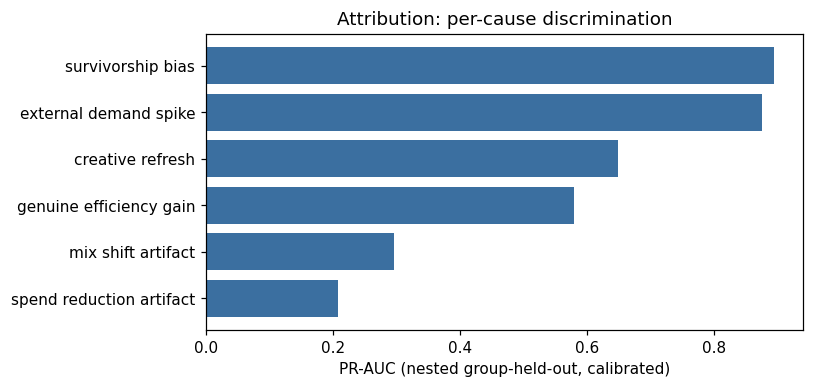

In [9]:
print(f"top-1 cause hit rate (nested group-held-out): {result['top1_hit_rate']:.2f}")

m = result["metrics"].dropna(subset=["pr_auc"]).sort_values("pr_auc")
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(m["cause"].str.replace("_", " "), m["pr_auc"], color="#3b6fa0")
ax.set_xlabel("PR-AUC (nested group-held-out, calibrated)"); ax.set_title("Attribution: per-cause discrimination")
plt.show()

### Analyst-facing narrative

Example output for a handful of flagged anomalies - this is the format proposed for the analyst review UI (see `design_proposal.md` -> *Explainability*):

In [10]:
flagged = scored[scored["flagged"] == True].merge(
    feat, on=["brand", "channel", "month", "month_idx"], how="left", suffixes=("", "_f")
)
for _, row in flagged.sample(3, random_state=7).iterrows():
    dist = predict_distribution(result["models"], row)
    print(narrate(row, dist))
    print()

Nimbus Home / display / 2025-09: alert score +2.5 robust std. devs vs. expected (sudden, single-month pattern).
  Most likely drivers -
  - external demand spike (95% calibrated likelihood): other channels/brands moved similarly in the same month - a category-wide demand shift is a plausible shared driver

Ridgeway Grocery / audio / 2025-03: alert score +0.9 robust std. devs vs. expected (sudden, single-month pattern).
  No cause clears a confident threshold. Treat this as 'flagged, unexplained' - the driver may sit outside the six-cause taxonomy (competitor action, macro shift, a reporting change). Worth an analyst's eyes before it goes in the monthly narrative.
  Closest match was external demand spike at 12%, below the 25% confidence bar.

Ridgeway Grocery / affiliate / 2024-10: alert score +1.1 robust std. devs vs. expected (gradual, multi-month pattern).
  No cause clears a confident threshold. Treat this as 'flagged, unexplained' - the driver may sit outside the six-cause taxonom

## 4. Limits of this notebook run

- Evaluated against *this run's* synthetic ground truth only - proves the method can recover the
  mechanisms we built into the simulator, not that the simulator matches reality.
- Per-cause attribution quality tracks how many injected examples of that cause exist in this
  run (see `n_pos` above); rarer causes have noisier out-of-fold estimates.
- Full discussion of production readiness, causal honesty, and where this breaks: `design_proposal.md`.